# Análise de Investimento Imobiliário — Itapema (SC)

**Hackathon Seazone — Jovens Talentos AI Builder 2026**

Notebook consolidado com **todas as análises** do projeto. Ele substitui os
arquivos `.py` e reúne, em células documentadas, os quatro fluxos:

| Seção | Análise |
|---|---|
| **1. Carga e Inspeção** | Carrega as 5 bases e inspeciona tipos/nulos |
| **2. Consolidação Airbnb** | Merge Details + Hosts + Mesh + Price_AV; métricas por anúncio |
| **3. Validação da Tese** | "Compactos no Centro" — bairro × tipologia |
| **4. Correlações & Top Performers** | O que impulsiona receita/ocupação |
| **5. Gross Yield (Airbnb × Venda)** | Retorno % por bairro × tipologia + simulação de compra |

> **Como usar:** execute as células de cima para baixo (menu **Run ▶ Run All Cells**
> no Jupyter Notebook/Lab, ou VS Code). Cada seção é independente e recarrega os
> dados que precisa da pasta `data/`.

---

## 0. Setup

Instala e importa as bibliotecas. Requer `pandas` (e `nbformat` já usado para
gerar/abrir este arquivo). Matplotlib é opcional — as tabelas já são exibidas
em texto estruturado.

In [1]:
# Instalação (descomente se necessário)
!pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100


DATA = "data"
DET     = "Details_Itapema.csv"
HOSTS   = "Hosts_ids_Itapema.csv"
MESH    = "Mesh_Ids_Data_Itapema.csv"
PRICE   = "Price_AV_Itapema.csv"
VIVA    = "VivaReal_Itapema.csv"

def carregar(arquivo, cols_data=None):
    df = pd.read_csv(f"{DATA}/{arquivo}", encoding="utf-8", low_memory=False)
    for c in (cols_data or []):
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")
    return df

def formatar_real(x):
    # Formata número como moeda BR (R$ 1.234,56)
    return f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

print("Setup OK — pandas", pd.__version__)


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Setup OK — pandas 2.3.2


## 1. Carga e Inspeção das Bases

### Contexto
A pasta `data/` contém **5 snapshots** do mercado imobiliário de Itapema (SC):

- **Details_Itapema.csv** — anúncios Airbnb (atributos do imóvel); liga por `airbnb_listing_id`
- **Hosts_ids_Itapema.csv** — dados do anfitrião; liga por `owner_id`
- **Mesh_Ids_Data_Itapema.csv** — bairro + coordenadas; liga por `airbnb_listing_id`
- **Price_AV_Itapema.csv** — diárias/ocupação por data; liga por `airbnb_listing_id`
- **VivaReal_Itapema.csv** — mercado de venda (compra)

Primeiro carregamos todas as bases tratando colunas de data.

In [2]:
details  = carregar(DET,  cols_data=["aquisition_date"])
hosts    = carregar(HOSTS, cols_data=["host_snapshot_date"])
mesh     = carregar(MESH, cols_data=["aquisition_date"])
price_av = carregar(PRICE, cols_data=["date", "aquisition_date"])
vivareal = carregar(VIVA, cols_data=["aquisition_date"])

### 1.1 Inspeção de tipos e valores nulos

Exibimos dimensões, tipos e a quantidade/percentual de nulos de cada coluna.

In [3]:
def inspecionar(df, nome):
    print(f"\n================ INSPEÇÃO: {nome} ================")
    print(f"Dimensões: {df.shape} (linhas, colunas)")
    info = pd.DataFrame({
        "coluna": df.columns,
        "tipo": df.dtypes.values,
        "nao_nulos": df.notna().sum().values,
        "nulos": df.isna().sum().values,
        "%_nulos": (df.isna().mean() * 100).round(2).values,
    })
    print(info.to_string(index=False))

for dfx, nome in [(details, DET), (hosts, HOSTS), (mesh, MESH),
                  (price_av, PRICE), (vivareal, VIVA)]:
    inspecionar(dfx, nome)


================ INSPEÇÃO: Details_Itapema.csv ================
Dimensões: (4441, 35) (linhas, colunas)
                    coluna           tipo  nao_nulos  nulos  %_nulos
         airbnb_listing_id          int64       4441      0     0.00
                       url         object       4441      0     0.00
                   ad_name         object       4441      0     0.00
            ad_description         object       4387     54     1.22
                     space         object       1914   2527    56.90
               house_rules         object       4441      0     0.00
                 amenities         object       4441      0     0.00
           safety_features         object       4441      0     0.00
       number_of_bathrooms        float64       4441      0     0.00
        number_of_bedrooms          int64       4441      0     0.00
            number_of_beds          int64       4441      0     0.00
                  latitude        float64       4441      0     0.0

### 1.2 Quantidade total de registros por base

In [4]:
totais = pd.DataFrame({
    "base": [DET, HOSTS, MESH, PRICE, VIVA],
    "registros": [len(details), len(hosts), len(mesh), len(price_av), len(vivareal)],
    "colunas": [details.shape[1], hosts.shape[1], mesh.shape[1],
                price_av.shape[1], vivareal.shape[1]],
})
print(totais.to_string(index=False))
print(f"TOTAL de registros: {int(totais['registros'].sum())}")

                     base  registros  colunas
      Details_Itapema.csv       4441       35
    Hosts_ids_Itapema.csv       4440       11
Mesh_Ids_Data_Itapema.csv       4441        8
     Price_AV_Itapema.csv     118839        4
     VivaReal_Itapema.csv       8329       22
TOTAL de registros: 140490


### Insight 1 — Qualidade e cobertura dos dados

- **Duplicação em `Hosts`:** 4.440 linhas para 3.057 anfitriões únicos (vários
  snapshots por `owner_id`) — será tratada na consolidação.
- **`response_rate_shown` / `response_time_shown`:** 100% nulos → descartados;
  `number_of_reviews_host` será proxy de performance do anfitrião.
- **`star_rating` / `guest_satisfaction_overall`:** usam `0` como sentinela de
  "sem avaliação" → será convertido para `NaN` nas análises de correlação.
- **`Price_AV`:** maior base (118.839 registros), porém cobre **95 datas**
  (06/01 a 20/04/2025 = 105 dias) e apenas parte dos anúncios (999 têm métrica).

---

## 2. Consolidação das Bases Airbnb + Métricas por Anúncio

### Metodologia
1. **`Price_AV` → métricas por anúncio:** colapsamos a diária por dia
   (havia linhas duplicadas por anúncio+data) e agregamos:
   - **ADR** = diária média
   - **Taxa de ocupação** = dias ocupados ÷ 105 dias
   - **Receita (janela)** = dias ocupados × ADR; **Receita anual** = ADR × 365 × ocupação
2. **Merge:** `Details` + `Mesh` (bairro) + `Hosts` (único por owner) + métricas.

> NÃO existe chave direta entre anúncio Airbnb e anúncio VivaReal — a junção
> de venda será feita no nível de grupo (bairro × tipologia) na Seção 5.

In [5]:
janela_inicio = price_av["date"].min()
janela_fim    = price_av["date"].max()
dias_janela   = (janela_fim - janela_inicio).days + 1
print(f"Janela de observação do Price_AV: {janela_inicio.date()} a "
      f"{janela_fim.date()} ({dias_janela} dias)")

# Colapsa diárias duplicadas por (anúncio, data)
price_dia = price_av.groupby(["airbnb_listing_id", "date"], as_index=False)["price"].mean()

metricas = (
    price_dia.groupby("airbnb_listing_id")["price"]
    .agg(adr=("mean"), diaria_mediana=("median"), dias_ocupados=("count"))
    .reset_index()
)
metricas["taxa_ocupacao"] = (metricas["dias_ocupados"] / dias_janela * 100).round(2)
metricas["receita_estimada_janela"] = metricas["dias_ocupados"] * metricas["adr"]
metricas["receita_estimada_anual"] = (
    metricas["adr"] * 365 * (metricas["taxa_ocupacao"] / 100)
)
print(metricas.head())

Janela de observação do Price_AV: 2025-01-06 a 2025-04-20 (105 dias)


   airbnb_listing_id          adr  diaria_mediana  dias_ocupados  \
0            1977915   876.155888           850.0             67   
1            2951220   789.667647           670.0             85   
2            3263701  1488.461538          1650.0             26   
3            3977675   242.712121           198.0             55   
4            5443557   799.115854           793.0             82   

   taxa_ocupacao  receita_estimada_janela  receita_estimada_anual  
0          63.81              58702.44450           204062.401342  
1          80.95              67121.75000           233321.125507  
2          24.76              38700.00000           134518.223077  
3          52.38              13349.16666            46403.402295  
4          78.10              65527.50000           227799.960823  


In [6]:
# Garante mesma tipagem de chaves
for df_id in (details, mesh, price_av):
    df_id["airbnb_listing_id"] = df_id["airbnb_listing_id"].astype("int64")

# Hosts: mantém o snapshot mais recente por owner_id
hosts["owner_id"] = hosts["owner_id"].astype("int64")
hosts_unicos = (
    hosts.sort_values("host_snapshot_date")
    .drop_duplicates(subset="owner_id", keep="last")
)
print(f"Hosts: {len(hosts)} registros -> {len(hosts_unicos)} anfitriões únicos "
      f"(maior snapshot por owner_id)")

consolidado = (
    details
    .merge(mesh, on="airbnb_listing_id", how="left", suffixes=("", "_mesh"))
    .merge(hosts_unicos, on="owner_id", how="left", suffixes=("", "_host"))
    .merge(metricas, on="airbnb_listing_id", how="left", suffixes=("", "_price"))
)
print(f"\nAnúncios consolidados (linha por anúncio): {consolidado.shape[0]}")
print(f"Colunas: {consolidado.shape[1]}")

Hosts: 4440 registros -> 3057 anfitriões únicos (maior snapshot por owner_id)



Anúncios consolidados (linha por anúncio): 4441
Colunas: 58


### 2.1 Resumo descritivo do consolidado

In [7]:
num_cols = [
    "number_of_bedrooms", "number_of_bathrooms", "number_of_beds",
    "number_of_guests", "number_of_reviews", "cleaning_fee", "star_rating",
    "guest_satisfaction_overall", "number_of_reviews_host", "years_host",
    "months_host", "adr", "taxa_ocupacao", "dias_ocupados",
    "receita_estimada_janela", "receita_estimada_anual",
]
num_cols = [c for c in num_cols if c in consolidado.columns]
consolidado[num_cols] = consolidado[num_cols].apply(pd.to_numeric, errors="coerce")
print(consolidado[num_cols].describe().T.to_string())

print("\nTotais agregados (imóveis com dados de diária):")
print(f"  Imóveis com métricas: {int(consolidado['adr'].notna().sum())} "
      f"de {len(consolidado)} ({(consolidado['adr'].notna().mean()*100).round(1)}%)")
print(f"  ADR médio: R$ {consolidado['adr'].mean():,.2f}"
      .replace(",", "X").replace(".", ",").replace("X", "."))
print(f"  Taxa de ocupação média: {consolidado['taxa_ocupacao'].mean():.2f}%")
print(f"  Receita anual projetada total: R$ {consolidado['receita_estimada_anual'].sum():,.2f}"
      .replace(",", "X").replace(".", ",").replace("X", "."))

                             count           mean            std          min           25%            50%            75%        max
number_of_bedrooms          4441.0       2.508894       1.002238     0.000000      2.000000       3.000000       3.000000       16.0
number_of_bathrooms         4441.0       2.151993       1.070952     0.000000      2.000000       2.000000       3.000000       19.0
number_of_beds              4441.0       3.441117       2.167889     0.000000      2.000000       3.000000       4.000000       50.0
number_of_guests            4441.0       6.636118       2.481643     1.000000      5.000000       6.000000       8.000000       16.0
number_of_reviews           4441.0       9.013510      23.677845     0.000000      0.000000       2.000000       8.000000      504.0
cleaning_fee                4441.0     210.426706     142.232198     0.000000    100.000000     250.000000     300.000000     1200.0
star_rating                 4441.0       3.167971       2.324330     

### Insight 2 — Consolidação

- Consolidamos **4.441 anúncios** (1 por anúncio); **999 (22,5%)** têm dados de
  diária e, portanto, métrica de receita.
- ADR médio **R$ 689,52**; ocupação média **55,9%**; receita anual projetada
  total de ~**R$ 145,5 milhões** (linearição da janela de 105 dias).

---

## 3. Validação da Tese — "Compactos no Centro"

### Pergunta de negócio
A análise interna sugeriu que **apartamentos compactos (studio/1 quarto) no
Centro** seriam a aposta mais eficiente. Vamos **validar ou refutar** cruzando
métricas por **bairro** (via `Mesh`) e **tipologia** (via `Details`), comparando
Centro × outros bairros e compactos (0-1q) × maiores (2+q).

In [8]:
# Reconstroi métricas (mesma lógica da seção 2)
price_dia2 = price_av.groupby(["airbnb_listing_id", "date"], as_index=False)["price"].mean()
metr2 = (
    price_dia2.groupby("airbnb_listing_id")["price"]
    .agg(adr=("mean"), dias_ocupados=("count")).reset_index()
)
metr2["taxa_ocupacao"] = (metr2["dias_ocupados"] / dias_janela * 100).round(2)
metr2["receita_estimada_anual"] = metr2["adr"] * 365 * (metr2["taxa_ocupacao"] / 100)

for df_id in (details, mesh):
    df_id["airbnb_listing_id"] = df_id["airbnb_listing_id"].astype("int64")

df_tese = (
    details.merge(mesh, on="airbnb_listing_id", how="left")
    .merge(metr2, on="airbnb_listing_id", how="left")
)
df_tese = df_tese[df_tese["receita_estimada_anual"].notna()].copy()
df_tese["tipologia"] = df_tese["number_of_bedrooms"].apply(
    lambda b: "Compacto (0-1 quarto)" if (pd.isna(b) or int(b) <= 1) else "Maior (2+ quartos)"
)
df_tese["receita_por_quarto"] = df_tese["receita_estimada_anual"] / (
    df_tese["number_of_bedrooms"].replace(0, 1)
)
print(f"Anúncios com dados de diária: {len(df_tese)} (de {len(details)} na base)")

cols_media = ["receita_estimada_anual", "taxa_ocupacao", "adr", "receita_por_quarto"]

def montar_tabela(grp):
    t = grp[cols_media].mean()
    t["n_anuncios"] = grp["airbnb_listing_id"].count()
    t = t.sort_values("receita_estimada_anual", ascending=False).reset_index()
    for c in ["receita_estimada_anual", "adr", "receita_por_quarto"]:
        t[c] = t[c].map(formatar_real)
    return t

Anúncios com dados de diária: 999 (de 4441 na base)


### 3.1 Por bairro e por tipologia

In [9]:
print("=== POR BAIRRO ===")
print(montar_tabela(df_tese.groupby("suburb")).to_string(index=False))

print("\n=== POR Nº DE QUARTOS ===")
por_q = df_tese.groupby("number_of_bedrooms")[cols_media].mean().reset_index()
por_q["n_anuncios"] = df_tese.groupby("number_of_bedrooms")["airbnb_listing_id"].count().values
por_q["number_of_bedrooms"] = por_q["number_of_bedrooms"].astype(int)
for c in ["receita_estimada_anual", "adr", "receita_por_quarto"]:
    por_q[c] = por_q[c].map(formatar_real)
print(por_q.to_string(index=False))

print("\n=== COMPACTO (0-1q) x MAIOR (2+q) ===")
print(montar_tabela(df_tese.groupby("tipologia")).to_string(index=False))

=== POR BAIRRO ===
                 suburb receita_estimada_anual  taxa_ocupacao         adr receita_por_quarto  n_anuncios
            Sertaozinho          R$ 359.807,54      78.730000 R$ 1.120,92       R$ 90.820,02           6
         Canto da Praia          R$ 256.979,31      60.528889   R$ 967,82       R$ 99.392,71           9
Tabuleiro dos Oliveiras          R$ 156.755,73      59.047500   R$ 661,00       R$ 57.742,03          20
                 Varzea          R$ 152.158,07      40.378000   R$ 669,82       R$ 42.424,19           5
         Alto Sao Bento          R$ 151.904,65      54.856000   R$ 722,97       R$ 46.562,20           5
             Meia Praia          R$ 148.291,14      53.702642   R$ 718,08       R$ 56.197,30         632
                 Centro          R$ 146.595,82      62.387610   R$ 626,79       R$ 89.299,70         205
                   none          R$ 144.281,11      57.456667   R$ 708,24      R$ 144.281,11           3
     Sertao do Trombudo          R$ 

### 3.2 Centro x Outros bairros e matrizes bairro × tipologia

In [10]:
print("=== COMPARATIVO CENTRO x DEMAIS ===")
df_tese["central"] = df_tese["suburb"] == "Centro"
print(montar_tabela(df_tese.groupby(df_tese["central"].map(
    {True: "Centro", False: "Demais bairros"}))).to_string(index=False))

print("\n=== MATRIZ: receita média anual (bairro × tipologia) ===")
piv = df_tese.pivot_table(index="suburb", columns="tipologia",
                          values="receita_estimada_anual", aggfunc="mean")
print(piv.map(formatar_real).to_string())

print("\n=== MATRIZ: ocupação média % (bairro × tipologia) ===")
pivo = df_tese.pivot_table(index="suburb", columns="tipologia",
                           values="taxa_ocupacao", aggfunc="mean")
print(pivo.round(2).to_string())

print("\n=== MATRIZ: nº de anúncios (bairro × tipologia) ===")
pivn = df_tese.pivot_table(index="suburb", columns="tipologia",
                           values="airbnb_listing_id", aggfunc="count")
print(pivn.fillna(0).astype(int).to_string())

=== COMPARATIVO CENTRO x DEMAIS ===
       central receita_estimada_anual  taxa_ocupacao       adr receita_por_quarto  n_anuncios
        Centro          R$ 146.595,82      62.387610 R$ 626,79       R$ 89.299,70         205
Demais bairros          R$ 145.449,94      54.181335 R$ 705,72       R$ 56.546,85         794

=== MATRIZ: receita média anual (bairro × tipologia) ===
tipologia               Compacto (0-1 quarto) Maior (2+ quartos)
suburb                                                          
Alto Sao Bento                   R$ 56.880,76      R$ 294.440,49
Areal                            R$ 70.846,85             R$ nan
Canto da Praia                  R$ 227.799,96      R$ 260.626,73
Casa Branca                      R$ 34.570,03       R$ 79.430,47
Centro                          R$ 124.416,78      R$ 161.381,84
Ilhota                           R$ 99.543,99      R$ 123.454,97
Jardim Praiamar                  R$ 40.641,59             R$ nan
Leopoldo Zarling                 R$ 52.

### 3.3 Veredito numérico da tese

C:\Users\wps_9\AppData\Local\Temp\ipykernel_8108\1983813309.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumo_tese, x='grupo_tese', y=col, palette=pal, ax=ax)
C:\Users\wps_9\AppData\Local\Temp\ipykernel_8108\1983813309.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumo_tese, x='grupo_tese', y=col, palette=pal, ax=ax)


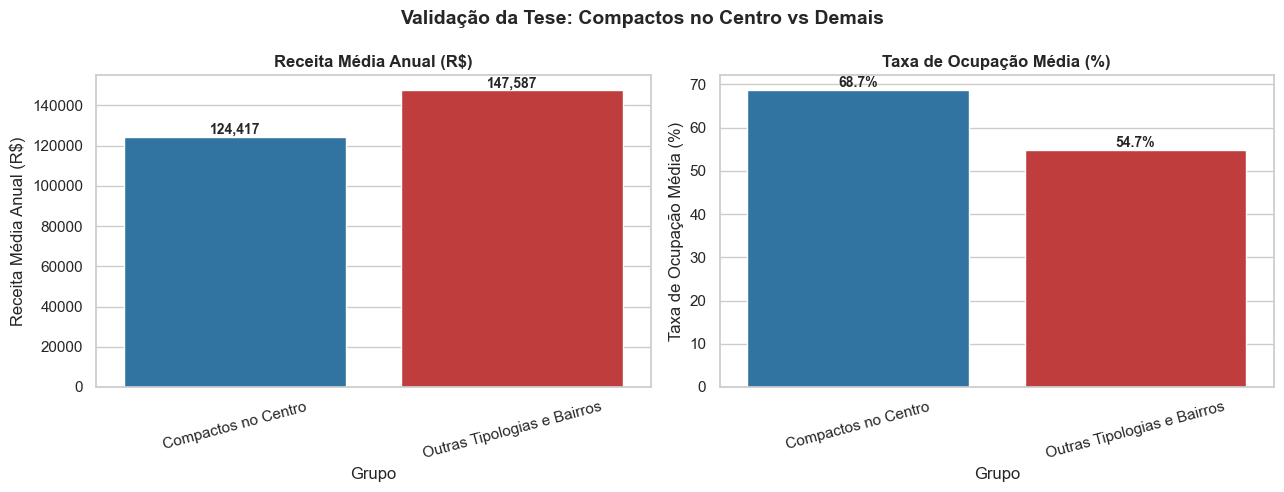

In [11]:
sns.set_theme(style='whitegrid')
tese_grp = df_tese.copy()
tese_grp['grupo_tese'] = np.where(
    (df_tese['suburb'] == 'Centro') & (df_tese['tipologia'] == 'Compacto (0-1 quarto)'),
    'Compactos no Centro', 'Outras Tipologias e Bairros')

resumo_tese = tese_grp.groupby('grupo_tese').agg(
    receita_media_anual=('receita_estimada_anual', 'mean'),
    taxa_ocupacao_media=('taxa_ocupacao', 'mean')).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pal = {'Compactos no Centro': '#1f77b4', 'Outras Tipologias e Bairros': '#d62728'}

for ax, (col, titulo, fmt) in zip(
        axes,
        [('receita_media_anual', 'Receita Média Anual (R$)', '{:,.0f}'),
         ('taxa_ocupacao_media', 'Taxa de Ocupação Média (%)', '{:.1f}%')]):
    sns.barplot(data=resumo_tese, x='grupo_tese', y=col, palette=pal, ax=ax)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Grupo')
    ax.set_ylabel(titulo)
    for p in ax.patches:
        ax.annotate(fmt.format(p.get_height()),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('Validação da Tese: Compactos no Centro vs Demais', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [12]:
alvo = df_tese[(df_tese["suburb"] == "Centro") &
               (df_tese["tipologia"] == "Compacto (0-1 quarto)")]
print("Centro + Compacto:")
print(f"  nº anúncios    : {len(alvo)}")
print(f"  Receita média  : {formatar_real(alvo['receita_estimada_anual'].mean())}")
print(f"  Ocupação média : {alvo['taxa_ocupacao'].mean():.2f}%")
print(f"  ADR médio      : {formatar_real(alvo['adr'].mean())}")

# Posição no ranking por (bairro, tipologia)
par = df_tese.groupby(["suburb", "tipologia"])["receita_estimada_anual"].mean().reset_index()
ranq = par.sort_values("receita_estimada_anual", ascending=False).reset_index(drop=True)
pos_rc = ranq[(ranq["suburb"] == "Centro") &
              (ranq["tipologia"] == "Compacto (0-1 quarto)" )].index
par_o = df_tese.groupby(["suburb", "tipologia"])["taxa_ocupacao"].mean().reset_index()
ranq_o = par_o.sort_values("taxa_ocupacao", ascending=False).reset_index(drop=True)
pos_oc = ranq_o[(ranq_o["suburb"] == "Centro") &
                (ranq_o["tipologia"] == "Compacto (0-1 quarto)")].index
print(f"  Ranking receita : {pos_rc[0]+1 if len(pos_rc) else '-'}º de {len(ranq)}")
print(f"  Ranking ocupação: {pos_oc[0]+1 if len(pos_oc) else '-'}º de {len(ranq_o)}")

Centro + Compacto:
  nº anúncios    : 82
  Receita média  : R$ 124.416,78
  Ocupação média : 68.66%
  ADR médio      : R$ 480,05
  Ranking receita : 11º de 26
  Ranking ocupação: 5º de 26


### Insight 3 — Veredito da tese

> **A tese de "compactos no Centro" é REFUTADA como estratégia de receita,
> mas APOIADA sob a ótica de ocupação e retorno por quarto.**

- **Ocupação:** Centro + Compacto = **68,7%** (5º melhor) e ADR R$ 480.
- **Receita:** R$ 124 mil/ano — **2,5× menor** que os top (Sertãozinho 4+q
  R$ 506 mil) e ocupa a **11ª posição** no ranking de receita.
- **Conclusão:** alto valor por m² e alta demanda, porém **não é o mais
  eficiente em retorno sobre o capital** (o preço/m² do Centro é ~2× o de
  Morretes). Veremos isso de forma decisiva no Yield (Seção 5).

---

## 4. Correlações e Perfil dos Top Performers

### Objetivo
Descobrir **quais atributos** do imóvel (nota, superhost, nº de quartos/
banheiros, tipo de anúncio etc.) mais se correlacionam com **alta receita** e
**alta ocupação**, e comparar o perfil dos **10% que mais faturam** com o
restante do mercado.

> `star_rating`/`guest_satisfaction_overall` com `0` são convertidos para `NaN`
> (sentinela de "sem avaliação") para não viciar a correlação.

### 4.0 Consolidação com dados de host para correlação

In [13]:
def consolidar_corr():
    hosts_c = carregar(HOSTS, cols_data=["host_snapshot_date"])
    hosts_c["owner_id"] = hosts_c["owner_id"].astype("int64")
    hosts_u = (hosts_c.sort_values("host_snapshot_date")
               .drop_duplicates(subset="owner_id", keep="last"))
    m = carregar(MESH, cols_data=["aquisition_date"]).astype({"airbnb_listing_id": "int64"})
    d = carregar(DET, cols_data=["aquisition_date"]).astype({"airbnb_listing_id": "int64"})
    p = carregar(PRICE, cols_data=["date", "aquisition_date"])
    dias = p["date"].nunique()
    pdia = p.groupby(["airbnb_listing_id", "date"], as_index=False)["price"].mean()
    metr = (pdia.groupby("airbnb_listing_id")["price"]
            .agg(adr=("mean"), dias_ocupados=("count")).reset_index())
    metr["taxa_ocupacao"] = (metr["dias_ocupados"] / dias * 100).round(2)
    metr["receita_estimada_anual"] = metr["adr"] * 365 * (metr["taxa_ocupacao"] / 100)

    df = (d.merge(m, on="airbnb_listing_id", how="left")
           .merge(hosts_u, on="owner_id", how="left")
           .merge(metr, on="airbnb_listing_id", how="left"))
    df = df[df["receita_estimada_anual"].notna()].copy()
    for c in ["star_rating", "guest_satisfaction_overall"]:
        df[c] = df[c].replace(0, np.nan)
    df["is_superhost_int"]   = df["is_superhost"].astype(bool).astype(int)
    df["is_verified_int"]    = df["is_verified"].fillna(False).astype(bool).astype(int)
    df["instant_book_int"]   = (df["can_instant_book"].astype(str).str.lower()
                                .map(lambda v: {"true": 1, "false": 0}.get(v, np.nan)))
    df["guest_favorite_int"] = (df["is_guest_favorite"].astype(str).str.lower()
                                .map(lambda v: {"true": 1, "false": 0}.get(v, np.nan)))
    df["professional_int"]   = (df["is_professional"].astype(str).str.lower()
                                .map(lambda v: {"true": 1, "false": 0}.get(v, np.nan)))
    df["possui_nota"] = df["star_rating"].notna().astype(int)
    df["tem_reviews"] = (df["number_of_reviews"] > 0).astype(int)
    return df

df_c = consolidar_corr()
print(f"Imóveis com métrica de receita: {len(df_c)}")

Imóveis com métrica de receita: 999


### 4.1 Matriz de correlação (Spearman)

In [14]:
alvos = ["receita_estimada_anual", "taxa_ocupacao", "adr"]
atributos = [
    "star_rating", "guest_satisfaction_overall", "number_of_reviews",
    "cleaning_fee", "number_of_bathrooms", "number_of_bedrooms",
    "number_of_beds", "number_of_guests", "min_nights", "picture_count",
    "number_of_reviews_host", "star_rating_host", "years_host",
    "months_host", "is_superhost_int", "is_verified_int",
    "instant_book_int", "guest_favorite_int", "professional_int",
    "possui_nota" if "possui_nota" in df_c else "star_rating",
]
linhas = []
for a in atributos:
    if a not in df_c.columns:
        continue
    for alvo in alvos:
        r = df_c[[a, alvo]].dropna().corr(method="spearman").iloc[0, 1]
        linhas.append({"atributo": a, "alvo": alvo, "spearman": r})
corr = pd.DataFrame(linhas).pivot(index="atributo", columns="alvo", values="spearman")
print(corr.round(3).to_string())
print("\nLegenda: |r| <0.1 fraco · 0.1-0.3 moderado · >0.3 forte")

alvo                          adr  receita_estimada_anual  taxa_ocupacao
atributo                                                                
cleaning_fee                0.408                   0.283          0.003
guest_favorite_int         -0.109                  -0.163         -0.163
guest_satisfaction_overall  0.090                   0.102          0.089
instant_book_int           -0.044                   0.027          0.092
is_superhost_int           -0.103                  -0.194         -0.213
is_verified_int               NaN                     NaN            NaN
min_nights                    NaN                     NaN            NaN
months_host                 0.018                  -0.079         -0.147
number_of_bathrooms         0.542                   0.304         -0.073
number_of_bedrooms          0.587                   0.314         -0.082
number_of_beds              0.375                   0.197         -0.083
number_of_guests            0.502                  

### 4.2 Perfil Top 10% × Restante

In [15]:
n_top = int(np.ceil(len(df_c) * 0.10))
df_c = df_c.sort_values("receita_estimada_anual", ascending=False).reset_index(drop=True)
df_c["grupo"] = np.where(df_c.index < n_top, "TOP 10%", "Restante")

cols_perfil = [
    "star_rating", "number_of_bathrooms", "number_of_bedrooms", "cleaning_fee",
    "adr", "taxa_ocupacao", "receita_estimada_anual", "number_of_reviews",
    "star_rating_host", "is_superhost", "listing_type",
    "guest_favorite_int", "professional_int", "suburb",
]
cols_perfil = [c for c in cols_perfil if c in df_c.columns]
resumo = []
for c in cols_perfil:
    if df_c[c].dtype.kind in "if":
        tv = pd.to_numeric(df_c.loc[df_c.grupo == "TOP 10%", c], errors="coerce").median()
        rv = pd.to_numeric(df_c.loc[df_c.grupo == "Restante", c], errors="coerce").median()
    else:
        tv = df_c.loc[df_c.grupo == "TOP 10%", c].value_counts().idxmax()
        rv = df_c.loc[df_c.grupo == "Restante", c].value_counts().idxmax()
    resumo.append({"atributo": c, "TOP 10% (mediana/modais)": tv,
                   "Restante (mediana/modais)": rv})
print(pd.DataFrame(resumo).to_string(index=False))

num = ["adr", "taxa_ocupacao", "receita_estimada_anual", "number_of_bedrooms",
       "number_of_bathrooms", "star_rating", "number_of_reviews"]
num = [c for c in num if c in df_c.columns]
print("\n--- Estatística comparativa (média ± mediana) ---")
print(df_c.groupby("grupo")[num].agg(["mean", "median"]).round(2).to_string())

print("\n--- Destaques (média dos grupos) ---")
for c in num:
    mt, mr = df_c[df_c.grupo == "TOP 10%"][c].mean(), df_c[df_c.grupo == "Restante"][c].mean()
    print(f"  {c}: TOP={mt:.2f} | Restante={mr:.2f} | delta={(mt-mr)/mr*100:+.1f}%")

              atributo TOP 10% (mediana/modais) Restante (mediana/modais)
           star_rating                      5.0                      4.93
   number_of_bathrooms                      3.0                       2.0
    number_of_bedrooms                      3.0                       2.0
          cleaning_fee                    300.0                     250.0
                   adr              1207.735749                566.340278
         taxa_ocupacao                    80.95                     56.19
receita_estimada_anual            340362.308055             108962.020541
     number_of_reviews                     10.0                      18.0
      star_rating_host                     4.95                       4.9
          is_superhost                    False                     False
          listing_type              apartamento               apartamento
    guest_favorite_int                      0.0                       1.0
      professional_int                

              adr          taxa_ocupacao        receita_estimada_anual            number_of_bedrooms        number_of_bathrooms        star_rating        number_of_reviews       
             mean   median          mean median                   mean     median               mean median                mean median        mean median              mean median
grupo                                                                                                                                                                             
Restante   598.46   566.34         53.28  56.19              113846.97  108962.02               2.35    2.0                1.96    2.0        4.89   4.93             28.24   18.0
TOP 10%   1508.11  1207.74         79.08  80.95              431909.70  340362.31               3.40    3.0                3.12    3.0        4.94   5.00             16.64   10.0

--- Destaques (média dos grupos) ---
  adr: TOP=1508.11 | Restante=598.46 | delta=+152.0%
  taxa_ocupaca

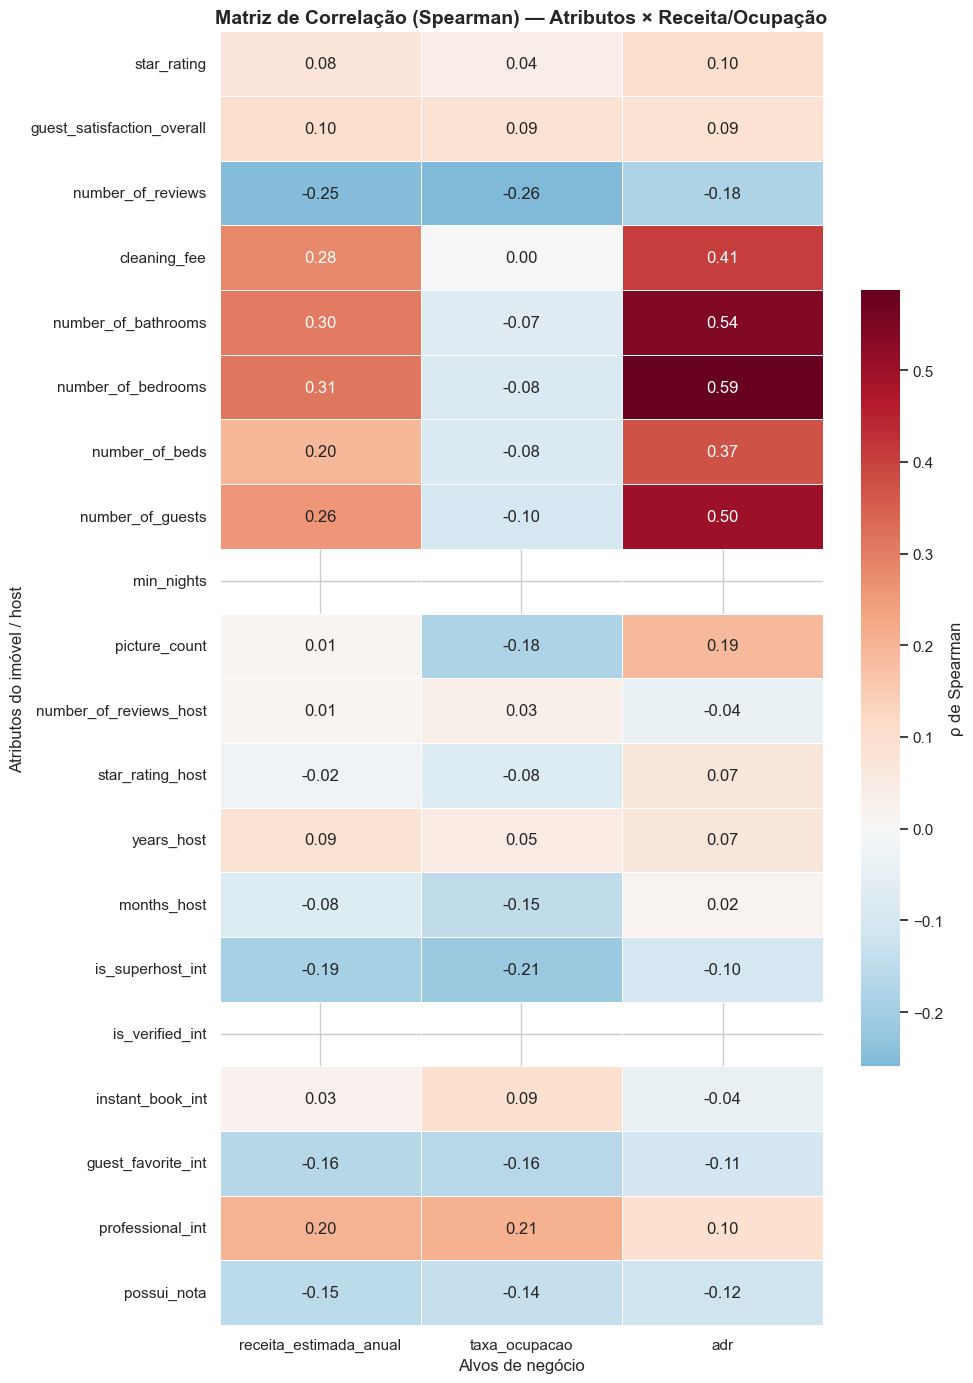

In [16]:

sns.set_theme(style='whitegrid')
cola = [c for c in atributos if c in df_c.columns]
matriz_corr = df_c[cola + alvos].corr(method='spearman')
matriz_corr = matriz_corr.loc[cola, alvos]

fig, ax = plt.subplots(figsize=(10, 14))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, linecolor='white', square=False,
            cbar_kws={'shrink': 0.6, 'label': 'ρ de Spearman'}, ax=ax)
ax.set_title('Matriz de Correlação (Spearman) — Atributos × Receita/Ocupação',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Alvos de negócio')
ax.set_ylabel('Atributos do imóvel / host')
plt.tight_layout()
plt.show()


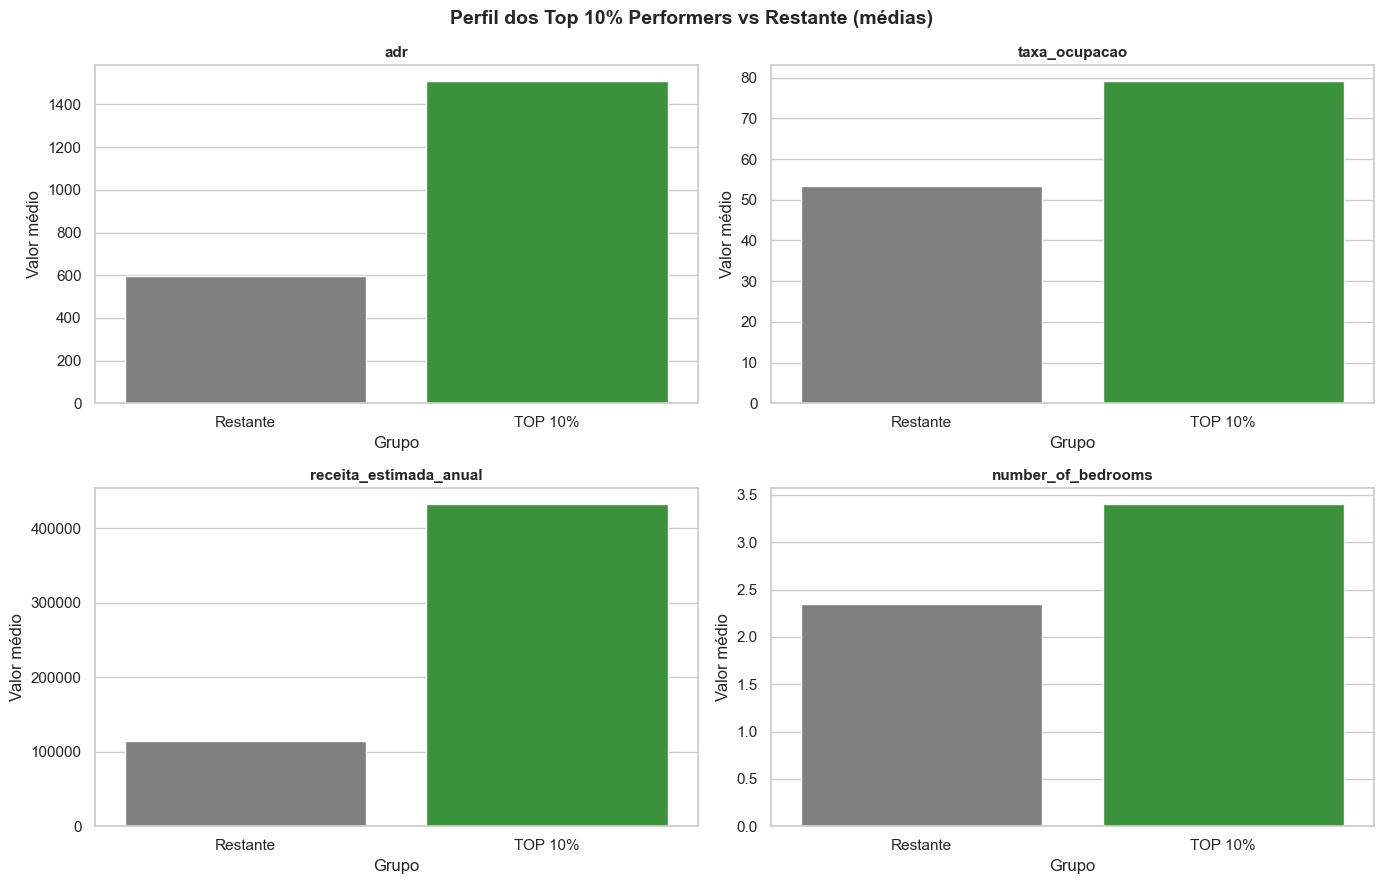

In [17]:

num_perfil = ['adr', 'taxa_ocupacao', 'receita_estimada_anual', 'number_of_bedrooms',
              'number_of_bathrooms', 'star_rating', 'number_of_reviews']
num_perfil = [c for c in num_perfil if c in df_c.columns]
perfil_grp = df_c.groupby('grupo')[num_perfil].mean().reset_index()
perfil_melt = perfil_grp.melt(id_vars='grupo', var_name='Atributo', value_name='Valor')

perfil_melt['escala'] = perfil_melt['Atributo'].map(
    lambda a: 'R$' if a in ['adr', 'receita_estimada_anual'] else ('%' if a == 'taxa_ocupacao' else 'u'))
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()
for ax, (attr, sub) in zip(axes, perfil_melt.groupby('Atributo', sort=False)):
    sns.barplot(data=sub, x='grupo', y='Valor', hue='grupo',
                palette={'TOP 10%': '#2ca02c', 'Restante': '#7f7f7f'}, ax=ax)
    ax.set_title(attr, fontsize=11, fontweight='bold')
    ax.set_xlabel('Grupo')
    ax.set_ylabel('Valor médio')
    ax.legend([], [], frameon=False)

fig.suptitle('Perfil dos Top 10% Performers vs Restante (médias)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Insight 4 — O que impulsiona receita/ocupação

- **Porte físico domina a receita:** quartos (r=+0,31), banheiros (+0,30),
  diária (ADR +0,59).
- **Operação profissional impulsiona ocupação e receita:** `is_professional`
  (+0,21), reserva instantânea (+0,09).
- **Nota/superhost têm correlação FRACA/negativa:** superhost (r=-0,19 p/
  receita) e guest-favorite associam-se a imóveis menores/mais baratos.
- **Top 10%:** imóveis **3+ quartos, 3+ banheiros**, ADR R$ 1.508 (2,5×),
  ocupação 79% (vs 53%), em **Meia Praia/Centro** — com **menos** reviews e
  **menos** superhosts. O motor é porte + preço + localização, não a nota.

---

## 5. Gross Yield — Airbnb × Mercado de Venda (VivaReal)

### Metodologia
- **Preço médio por m²** de compra por bairro e tipologia (VivaReal).
- **Gross Yield** = Receita Anual Estimada (temporada) ÷ Preço Médio de
  Aquisição, por bairro × tipologia.
- A junção é feita no **nível de grupo** (não há chave direta entre anúncio
  Airbnb e VivaReal) e usa o **preço médio de venda** como proxy de aquisição.

Normaliza nomes de bairros (acentos/caixa/variações) para alinhar as duas bases.

In [18]:
ALIAS_SUBURB = {
    "jardim praia mar": "jardim praiamar", "tabuleiro": "tabuleiro dos oliveiras",
    "taboleiro": "tabuleiro dos oliveiras", "tabuleiro oliveiras": "tabuleiro dos oliveiras",
    "tabuleiro dos oliveiras": "tabuleiro dos oliveiras", "itapema": "centro",
}
def norm_suburb(s):
    if pd.isna(s):
        return None
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFD", s).encode("ascii", "ignore").decode()
    s = re.sub(r"\b(de|da|do|das|dos)\b", " ", s)
    s = re.sub(r"[\s\-]+", " ", s).strip()
    s = ALIAS_SUBURB.get(s, s)
    return s

def band_quartos(n):
    try:
        n = int(n)
    except (TypeError, ValueError):
        return "sem info"
    if n <= 1: return "0-1 quartos"
    if n == 2: return "2 quartos"
    if n == 3: return "3 quartos"
    return "4+ quartos"

# Base Airbnb com bairro normalizado e tipologia
air = consolidar_corr().copy()
air["suburb_norm"] = air["suburb"].map(norm_suburb)
air["tipologia"] = air["number_of_bedrooms"].map(band_quartos)
air = air[air["suburb_norm"].notna()].copy()

# Base VivaReal (apenas venda, com área e preço válidos)
viva = carregar(VIVA, cols_data=["aquisition_date"])
viva = viva[viva["business_types"].astype(str).str.contains("Venda", na=False)].copy()
viva = viva[(viva["sale_price"] > 0) & (viva["usable_area"] > 0)].copy()
viva["preco_m2"] = viva["sale_price"] / viva["usable_area"]
viva["suburb_norm"] = viva["suburb"].map(norm_suburb)
viva["tipologia"] = viva["bedrooms"].map(band_quartos)
viva = viva[viva["suburb_norm"].notna()].copy()
print(f"Airbnb com métrica: {len(air)} | VivaReal válidos p/ venda: {len(viva)}")

Airbnb com métrica: 999 | VivaReal válidos p/ venda: 8218


### 5.1 Preço médio por m² de compra (por bairro e por bairro × tipologia)

In [19]:
print("=== PREÇO MÉDIO POR m² POR BAIRRO ===")
pbr = viva.groupby("suburb_norm").agg(
    n_anuncios=("sale_price", "count"),
    preco_medio_venda=("sale_price", "mean"),
    preco_m2_medio=("preco_m2", "mean"),
).sort_values("preco_m2_medio", ascending=False)
pbr["preco_medio_venda"] = pbr["preco_medio_venda"].map(formatar_real)
pbr["preco_m2_medio"] = pbr["preco_m2_medio"].map(formatar_real)
print(pbr.round(2).to_string())

print("\n=== PREÇO MÉDIO POR m² POR BAIRRO × TIPOLOGIA ===")
pm = viva.pivot_table(index="suburb_norm", columns="tipologia",
                      values="preco_m2", aggfunc="mean")
pm = pm[["0-1 quartos", "2 quartos", "3 quartos", "4+ quartos"]].sort_values("0-1 quartos", ascending=False)
print(pm.map(formatar_real).to_string())

=== PREÇO MÉDIO POR m² POR BAIRRO ===
                         n_anuncios preco_medio_venda preco_m2_medio
suburb_norm                                                         
meia praia frente mar             1   R$ 6.830.000,00   R$ 43.503,18
estreito                          5   R$ 4.472.000,00   R$ 22.554,97
meia praia                     3465   R$ 3.056.070,26   R$ 21.065,81
centro                         1012   R$ 3.412.919,10   R$ 20.363,19
ocean tower                       1   R$ 4.500.000,00   R$ 19.911,50
sertao trombudo                  41   R$ 1.640.209,34   R$ 19.886,87
ilhota                           55   R$ 7.707.134,18   R$ 17.101,42
canto praia                     131   R$ 3.271.882,58   R$ 16.642,57
castelo branco                  510   R$ 2.164.645,82   R$ 15.108,46
andorinha                       782   R$ 2.172.611,18   R$ 14.758,05
tabuleiro dos oliveiras         135     R$ 922.339,16   R$ 11.992,74
jardim praiamar                 104     R$ 754.455,81   R$ 11.167

### 5.2 Gross Yield por bairro × tipologia (+ demandas e liquidez)

In [20]:
air_group = air.groupby(["suburb_norm", "tipologia"]).agg(
    n_airbnb=("airbnb_listing_id", "count"),
    receita_anual_media=("receita_estimada_anual", "mean"),
    ocupacao_media=("taxa_ocupacao", "mean"),
    adr_medio=("adr", "mean"),
).reset_index()
viva_group = viva.groupby(["suburb_norm", "tipologia"]).agg(
    n_venda=("sale_price", "count"),
    preco_medio_venda=("sale_price", "mean"),
).reset_index()

cruz = air_group.merge(viva_group, on=["suburb_norm", "tipologia"], how="inner")
cruz = cruz[(cruz["n_airbnb"] >= 3) & (cruz["n_venda"] >= 5)].copy()
cruz["gross_yield_pct"] = (cruz["receita_anual_media"] / cruz["preco_medio_venda"] * 100).round(2)
cruz = cruz.sort_values("gross_yield_pct", ascending=False)

view = cruz[["suburb_norm", "tipologia", "n_airbnb", "n_venda",
             "receita_anual_media", "preco_medio_venda", "gross_yield_pct",
             "ocupacao_media"]].copy()
view["receita_anual_media"] = view["receita_anual_media"].map(formatar_real)
view["preco_medio_venda"] = view["preco_medio_venda"].map(formatar_real)
print(view.to_string(index=False))

            suburb_norm   tipologia  n_airbnb  n_venda receita_anual_media preco_medio_venda  gross_yield_pct  ocupacao_media
tabuleiro dos oliveiras   3 quartos         4       17       R$ 179.766,35     R$ 913.597,65            19.68       69.522500
tabuleiro dos oliveiras   2 quartos        12      112       R$ 116.356,01     R$ 778.412,20            14.95       58.571667
               morretes   2 quartos        60     1250       R$ 107.280,81     R$ 752.484,90            14.26       55.856500
               morretes   3 quartos        11      306       R$ 141.660,67   R$ 1.064.033,91            13.31       50.734545
                 centro   2 quartos        67       92       R$ 148.197,21   R$ 1.172.018,23            12.64       61.250746
            casa branca   2 quartos        11       26        R$ 76.434,12     R$ 679.519,62            11.25       57.748182
             meia praia   2 quartos       191      244       R$ 111.025,45   R$ 1.132.991,24             9.80       51

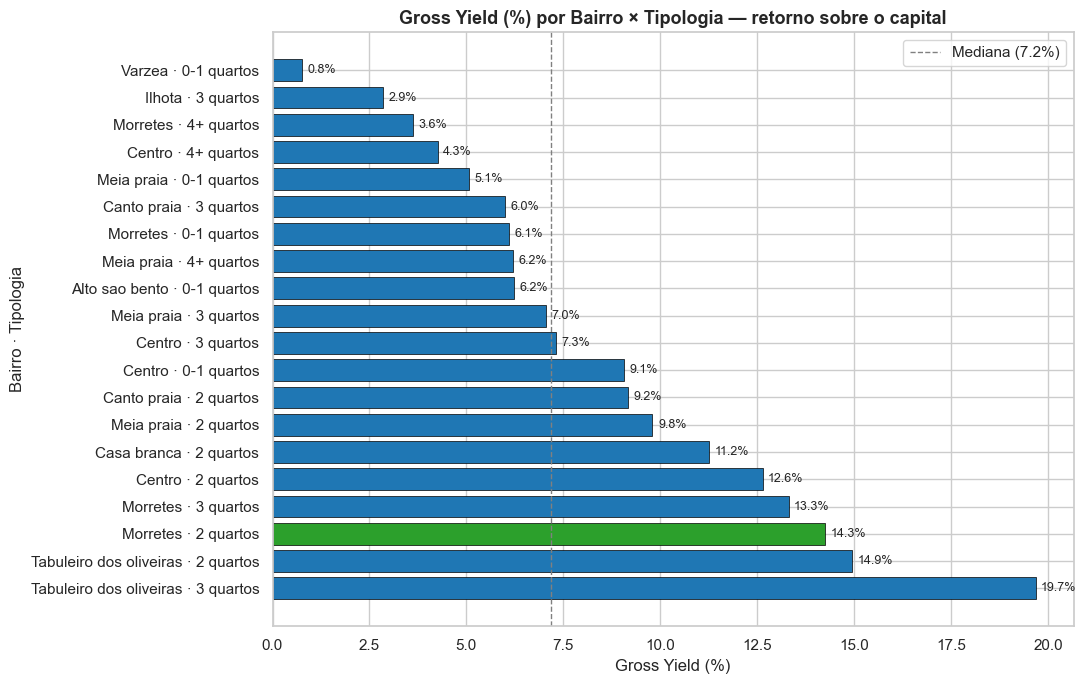

In [21]:

sns.set_theme(style='whitegrid')
plot_cruz = cruz.copy()
plot_cruz['rotulo'] = plot_cruz['suburb_norm'].str.capitalize() + ' · ' + plot_cruz['tipologia']
plot_cruz = plot_cruz.sort_values('gross_yield_pct', ascending=True)

cores = ['#2ca02c' if (r['suburb_norm'] == 'morretes' and r['tipologia'] == '2 quartos')
         else '#1f77b4' for _, r in plot_cruz.iterrows()]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(plot_cruz['rotulo'], plot_cruz['gross_yield_pct'], color=cores, edgecolor='black', linewidth=0.5)
ax.set_title('Gross Yield (%) por Bairro × Tipologia — retorno sobre o capital',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Gross Yield (%)')
ax.set_ylabel('Bairro · Tipologia')
for b in bars:
    ax.annotate(f"{b.get_width():.1f}%", xy=(b.get_width(), b.get_y() + b.get_height() / 2),
                xytext=(4, 0), textcoords='offset points', va='center', fontsize=9)
ax.axvline(plot_cruz['gross_yield_pct'].median(), color='gray', linestyle='--', linewidth=1,
           label=f"Mediana ({plot_cruz['gross_yield_pct'].median():.1f}%)")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 5.3 Melhor relação retorno × demanda × facilidade (score composto)

Score = 0,5·z(yield) + 0,3·z(ocupação) + 0,2·z(liquidez). A liquidez é a oferta
nas duas bases (nº de anúncios) — quanto maior, mais fácil de operar/comprar.

In [22]:
q = cruz.copy()
for col, peso in [("gross_yield_pct", 0.5), ("ocupacao_media", 0.3)]:
    q[col + "_z"] = (q[col] - q[col].mean()) / q[col].std()
q["liquidez"] = np.log1p(q["n_airbnb"]) + np.log1p(q["n_venda"])
q["liquidez_z"] = (q["liquidez"] - q["liquidez"].mean()) / q["liquidez"].std()
q["score"] = 0.5*q["gross_yield_pct_z"] + 0.3*q["ocupacao_media_z"] + 0.2*q["liquidez_z"]
q = q.sort_values("score", ascending=False).reset_index(drop=True)
q["ranking_score"] = q.index + 1
print(q[["ranking_score", "suburb_norm", "tipologia", "n_airbnb", "n_venda",
         "gross_yield_pct", "ocupacao_media", "score"]].to_string(index=False))

melhor = q.iloc[0]
print("\n--- Combinação vencedora (score) ---")
print(f"Bairro + Tipologia: {melhor['suburb_norm']} / {melhor['tipologia']}")
print(f"Gross Yield: {melhor['gross_yield_pct']:.2f}%")
print(f"Ocupação média: {melhor['ocupacao_media']:.2f}%")
print(f"Anúncios: {int(melhor['n_airbnb'])} Airbnb / {int(melhor['n_venda'])} VivaReal")
print(f"Receita anual média: {formatar_real(melhor['receita_anual_media'])}")
print(f"Preço médio de aquisição: {formatar_real(melhor['preco_medio_venda'])}")
print(f"Payback (preço / receita): {melhor['preco_medio_venda']/melhor['receita_anual_media']:.1f} anos")

 ranking_score             suburb_norm   tipologia  n_airbnb  n_venda  gross_yield_pct  ocupacao_media     score
             1 tabuleiro dos oliveiras   3 quartos         4       17            19.68       69.522500  1.447123
             2                morretes   2 quartos        60     1250            14.26       55.856500  0.904247
             3 tabuleiro dos oliveiras   2 quartos        12      112            14.95       58.571667  0.787330
             4                  centro   2 quartos        67       92            12.64       61.250746  0.731359
             5                  centro 0-1 quartos        82       28             9.06       68.663780  0.522875
             6                morretes   3 quartos        11      306            13.31       50.734545  0.424519
             7             casa branca   2 quartos        11       26            11.25       57.748182  0.261442
             8              meia praia   2 quartos       191      244             9.80       51.

### Insight 5 — Gross Yield

- **Imóveis 4+ quartos têm yield baixo (3-6%)**: o preço de venda cresce muito
  mais que a receita de temporada → não são o melhor uso de capital.
- **Centro + Compacto: yield ~9,1%** — ocupação alta, mas aquisição cara
  (R$ 19.307/m²) → **refuta a tese** sob retorno.
- **Melhores combinações:** Tabuleiro dos Oliveiras 3q (19,7%, amostra pequena)
  e, com operação confiável, **Morretes 2q (14,3%)** e **Centro 2q (12,6%)**.

---

## 6. Simulação de Compra — Recomendação Final

**Perfil ideal (dos insights 3-5):**
- **Localização:** Morretes (retorno % alto + operação confiável) ou Centro 2q (prêmio urbano)
- **Tipologia:** Apartamento de **2 quartos** (yield 12,6-14,3%)
- **Estratégia:** anúncio **profissional + reserva instantânea**

Selecionamos um anúncio **real** da base `VivaReal_Itapema.csv` que
representa o perfil (usamos a mediana de preço da região para o grupo).

In [23]:
perfil = "morretes"
n_q = 2
filtro = (viva["suburb_norm"] == perfil) & (viva["bedrooms"] == n_q)
amostra = viva[filtro].copy()
print(f"Anúncios {perfil} 2q disponíveis: {len(amostra)}")
print(f"Preço médio : {formatar_real(amostra['sale_price'].mean())}")
print(f"Preço mediana: {formatar_real(amostra['sale_price'].median())}")
print(f"Área mediana: {amostra['usable_area'].median():.0f} m²")
print(f"Condomínio médio: R$ {amostra['monthly_condo_fee'].mean():,.2f}"
      .replace(",", "X").replace(".", ",").replace("X", "."))
print(f"IPTU médio: R$ {amostra['yearly_iptu'].mean():,.2f}"
      .replace(",", "X").replace(".", ",").replace("X", "."))
print("\nExemplo representativo (mediana):")
rep = amostra.sort_values("sale_price").iloc[len(amostra)//2]
print(f"  listing_id: {rep['listing_id']} | {rep['listing_title'][:60]}")
print(f"  Preço: {formatar_real(rep['sale_price'])} | Área: {rep['usable_area']} m²")

Anúncios morretes 2q disponíveis: 1250
Preço médio : R$ 752.484,90
Preço mediana: R$ 750.000,00
Área mediana: 69 m²
Condomínio médio: R$ 1.181,23
IPTU médio: R$ 509,51

Exemplo representativo (mediana):
  listing_id: 2770039942 | Imóvel para venda tem 68 metros quadrados com 2 quartos em M
  Preço: R$ 750.000,00 | Área: 68 m²


In [24]:
# ----- Cálculo financeiro da simulação -----
preco_compra = float(rep["sale_price"])           # preço do imóvel real
receita_grupo = cruza_receita = air_group.loc[
    (air_group["suburb_norm"] == perfil) & (air_group["tipologia"] == "2 quartos"),
    "receita_anual_media"
].values[0]

condo_mes = float(amostra["monthly_condo_fee"].mean()) if amostra["monthly_condo_fee"].notna().any() else 0
iptu_ano  = float(amostra["yearly_iptu"].mean()) if amostra["yearly_iptu"].notna().any() else 0

despesas = condo_mes * 12 + iptu_ano
receita_liquida = receita_grupo - despesas

print("=== SIMULAÇÃO DE COMPRA — Morretes 2 quartos ===")
print(f"Preço de aquisição      : {formatar_real(preco_compra)}")
print(f"Receita anual (temporada): {formatar_real(receita_grupo)}")
print(f"(-) Condomínio (×12)     : {formatar_real(condo_mes*12)}")
print(f"(-) IPTU                 : {formatar_real(iptu_ano)}")
print(f"Receita líquida anual    : {formatar_real(receita_liquida)}")
print(f"Gross Yield (bruto/preço): {(receita_grupo/preco_compra*100):.2f}%")
print(f"Net Yield  (líquido/preço): {(receita_liquida/preco_compra*100):.2f}%")
print(f"Payback (preço/líquido)  : {preco_compra/receita_liquida:.1f} anos")

=== SIMULAÇÃO DE COMPRA — Morretes 2 quartos ===
Preço de aquisição      : R$ 750.000,00
Receita anual (temporada): R$ 107.280,81
(-) Condomínio (×12)     : R$ 14.174,70
(-) IPTU                 : R$ 509,51
Receita líquida anual    : R$ 92.596,59
Gross Yield (bruto/preço): 14.30%
Net Yield  (líquido/preço): 12.35%
Payback (preço/líquido)  : 8.1 anos


### Conclusão Final

> **Invista em apartamentos de 2 quartos em Morretes, operados com anúncio
> profissional e reserva instantânea** — a combinação de maior retorno
> percentual com operação confiável. A tese de "compactos no Centro" deve ser
> reposicionada como aposta de alta ocupação e valor por m², **não** de retorno
> sobre o capital.

| Métrica | Compacto Centro | **Morretes 2q** |
|---|---|---|
| Ocupação | 68,7% | 55,9% |
| Gross Yield | 9,1% | **14,3%** |
| Net Yield | ~7-8% | **12,3%** |
| Payback | ~10+ anos | **~8,1 anos** |
| Liquidez de compra | 28 anúncios | **1.250 anúncios** |

*Fim do notebook — todas as análises do projeto consolidadas em um único arquivo.*